# Fragrance retrieval relevance

This notebook reads the single-assessor grading workbook. It checks the 50 annotations, recomputes precision and strong-fit rates from the hidden retrieval ranks, and shows report-ready case results. It does not modify the workbook. A grade assesses a material from its odor descriptors, not a finished fragrance or an actual smell test.


## Scope of this evidence

These grades measure the relevance of retrieved fragrance materials for five descriptors. They do not measure the current DeepSeek judge, CLIP image-text similarity, or participant ratings. Keep this result separate from the paired human-study analysis.


In [2]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def find_eval_dir():
    for base in (Path.cwd(), *Path.cwd().parents):
        candidate = base / "eval"
        if (candidate / "comparison" / "retrieval" / "relevance_grading.xlsx").is_file():
            return candidate
    raise FileNotFoundError("Run from the repository or its eval/notebook directory")


EVAL = find_eval_dir()
WORKBOOK = EVAL / "comparison" / "retrieval" / "relevance_grading.xlsx"
print(WORKBOOK)


d:\CM3070_Brandbit\eval\comparison\retrieval\relevance_grading.xlsx


In [3]:
grades = pd.read_excel(WORKBOOK, sheet_name="Grade")
hits = pd.read_excel(WORKBOOK, sheet_name="Provenance", nrows=50)
assert len(grades) == len(hits) == 50
assert grades["hit_id"].is_unique and hits["hit_id"].is_unique
assert grades["relevance_0_1_2"].notna().all(), "Finish all manual grades first"
assert grades["relevance_0_1_2"].isin([0, 1, 2]).all()
assert set(grades["hit_id"]) == set(hits["hit_id"])
assert grades.groupby("case_id").size().eq(10).all()
assert hits.groupby("case_id")["rank"].apply(lambda ranks: sorted(ranks.tolist()) == list(range(1, 11))).all()

study = grades.merge(
    hits[["hit_id", "case_id", "execution_id", "rank", "query", "sources", "cid"]],
    on=["hit_id", "case_id"], validate="one_to_one",
).sort_values(["case_id", "rank"])
study["grade"] = study["relevance_0_1_2"].astype(int)
print("Cases:", study["case_id"].nunique(), "| graded materials:", len(study))
display(study["grade"].value_counts().sort_index().rename_axis("grade").to_frame("count"))


Cases: 5 | graded materials: 50


,count
grade,
0,5
1,19
2,26


In [4]:
records = []
for (case_id, execution_id), group in study.groupby(["case_id", "execution_id"], sort=True):
    ordered = group.sort_values("rank")
    record = {"case_id": case_id, "image": execution_id}
    for k in (5, 10):
        top = ordered.head(k)
        record[f"precision_at_{k}"] = (top["grade"] >= 1).mean()
        record[f"strong_fit_at_{k}"] = (top["grade"] == 2).mean()
    records.append(record)

case_results = pd.DataFrame(records).set_index(["case_id", "image"])
macro = case_results.mean().rename("Macro mean")
display(case_results.round(3))
display(macro.to_frame("value").round(3))

saved = pd.read_excel(WORKBOOK, sheet_name="Results", nrows=5).set_index("case_id")
for metric in macro.index:
    expected = case_results.reset_index().set_index("case_id")[metric]
    assert (saved.loc[expected.index, metric].sub(expected).abs() < 1e-9).all(), metric
print("Recomputed case values match the saved Results sheet.")


,,precision_at_5,strong_fit_at_5,precision_at_10,strong_fit_at_10
case_id,image,,,,
C01,Axioo_Pongo_001,1.0,0.4,1.0,0.3
C02,BatikKeris_001,0.2,0.2,0.5,0.3
C03,Indomie_001,1.0,0.4,1.0,0.7
C04,Singa_Watch_001,1.0,0.2,1.0,0.4
C05,Tulola_Jewellery_001,1.0,0.8,1.0,0.9


,value
precision_at_5,0.84
strong_fit_at_5,0.40
precision_at_10,0.90
strong_fit_at_10,0.52


Recomputed case values match the saved Results sheet.


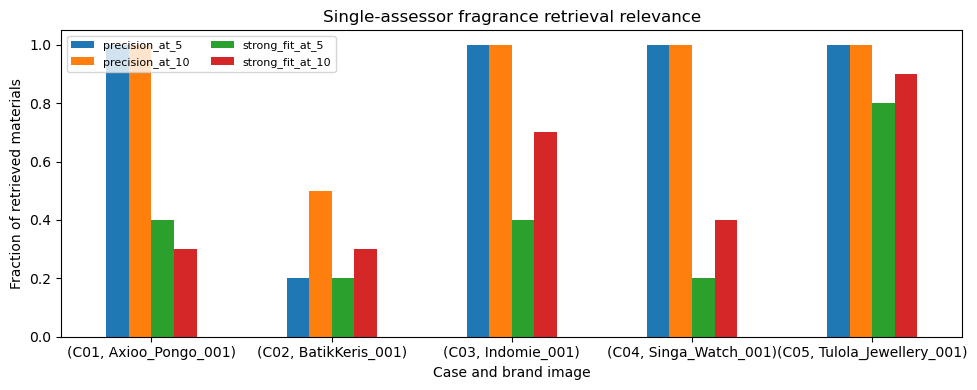

In [5]:
ax = case_results[["precision_at_5", "precision_at_10", "strong_fit_at_5", "strong_fit_at_10"]].plot(
    kind="bar", figsize=(10, 4), ylim=(0, 1.05), rot=0
)
ax.set_ylabel("Fraction of retrieved materials")
ax.set_xlabel("Case and brand image")
ax.set_title("Single-assessor fragrance retrieval relevance")
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()


In [6]:
weakest_case = case_results["precision_at_5"].idxmin()[0]
print("Lowest precision@5:", weakest_case)
display(study.loc[study["case_id"] == weakest_case,
                  ["rank", "ingredient", "odor_descriptors", "grade", "reason", "sources"]].sort_values("rank"))


Lowest precision@5: C02


,rank,ingredient,odor_descriptors,grade,reason,sources
14,1,dihydrofarnesol,floral; metallic; cyclamen,2,"floral, okay",goodscents
11,2,1-hexen-3-one,vegetable; cooked; metallic; green; green meta...,0,no plastic smell.,goodscents; leffingwell
13,3,nerylacetone,metallic; fatty,0,no fatty,goodscents
16,4,5-methyl-3-hexen-2-one,metallic; berry; cheesy; somewhat blue cheese;...,0,no cheese smell,leffingwell
17,5,1-hepten-3-one,metallic,0,no metallic only type of smell,goodscents
18,6,2-butoxyethylbenzene,metallic; mushroom; floral; watercress; green;...,1,"adding mushroom aroma, is unique.",goodscents
12,7,5-methyl-2-hepten-4-one,hazelnut; nutty; metallic; characteristic haze...,1,batik shouldn't be too nutty,goodscents; leffingwell
19,8,1-hepten-3-ol,metallic; spicy; mushroom; fruity; oily; tomat...,0,"this is food kindlike of smell, does not suit ...",goodscents; leffingwell
15,9,"4-hexen-3-one, (4z)-",spicy; green; tropical; metallic; horseradish;...,2,this is good,leffingwell
10,10,(2-isopropoxyethyl)benzene,metallic; spicy; foliage; rose; plastic; water...,2,"for batik shirt its quite simple, as long as i...",goodscents
